<a href="https://colab.research.google.com/github/hiranshree/AIML/blob/main/weather_sensitivity_heatmap_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_21907/483961606.py:40: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  elec_df['Timestamp'] = pd.to_datetime(elec_df[e_time_col]).dt.round('H').dt.tz_localize(None)
/tmp/ipykernel_21907/483961606.py:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  weather_df['Timestamp'] = pd.to_datetime(weather_df[w_time_col]).dt.round('H').dt.tz_localize(None)


Successfully merged 8784 rows.


/tmp/ipykernel_21907/483961606.py:87: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(valid[col], valid['air_temperature'])
/tmp/ipykernel_21907/483961606.py:87: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(valid[col], valid['air_temperature'])
/tmp/ipykernel_21907/483961606.py:87: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(valid[col], valid['air_temperature'])
/tmp/ipykernel_21907/483961606.py:87: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(valid[col], valid['air_temperature'])
/tmp/ipykernel_21907/483961606.py:87: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(valid[col], valid['air_temperature'])
/tmp/ipykernel_21907/483961606.py:87: Co

Success! Heatmap saved as ECCG_weather_sensitivity_heatmap.png


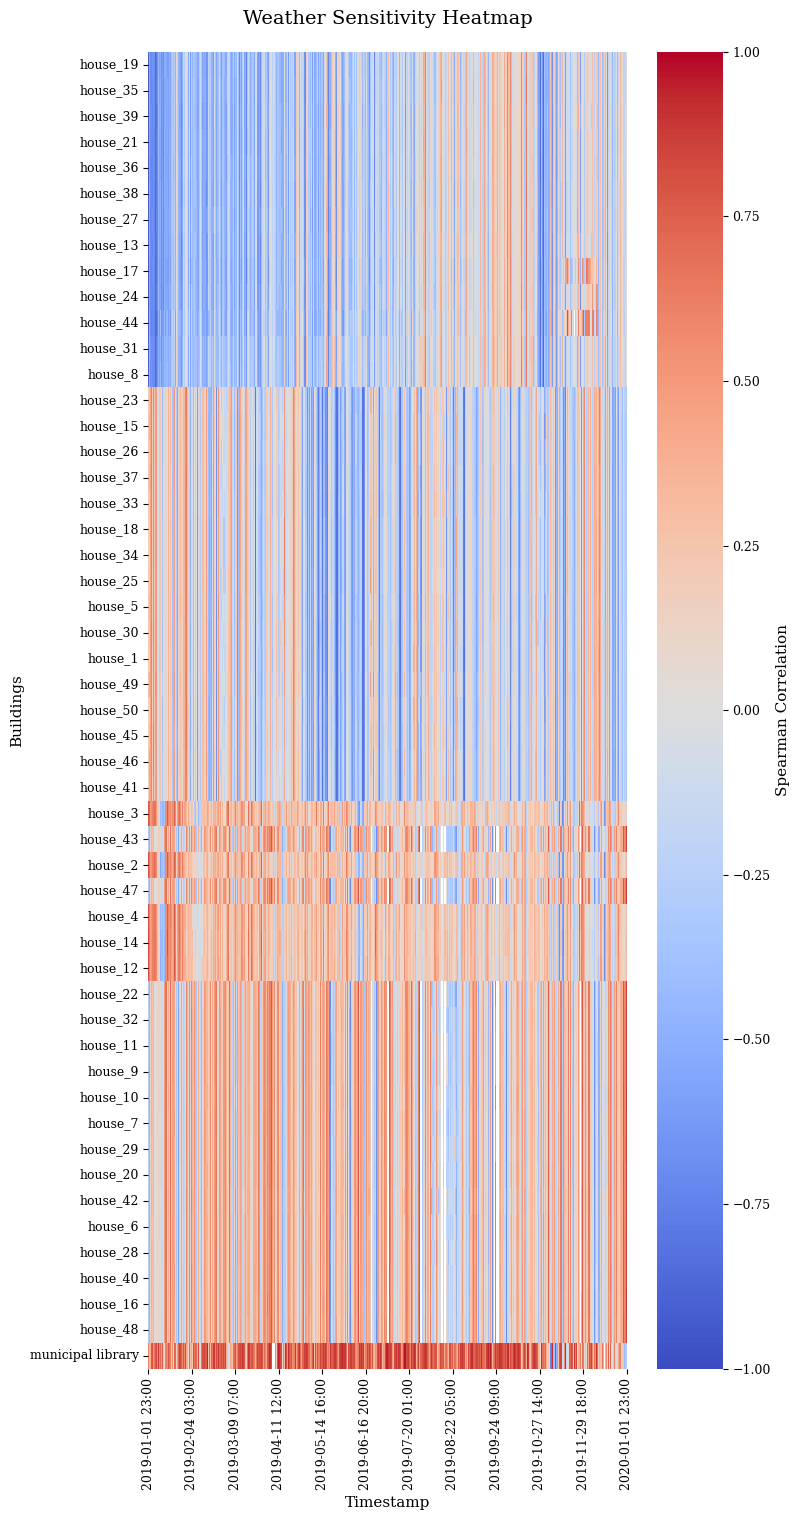

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from pathlib import Path

def weather_sensitivity_plot(electricity_file, weather_file, window_size=24):
    # --- LATEX FONT CONFIGURATION ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.edgecolor": "black",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    # 1. Load data
    try:
        elec_df = pd.read_csv(electricity_file)
        weather_df = pd.read_csv(weather_file)

        # Strip hidden spaces from column names
        elec_df.columns = elec_df.columns.str.strip()
        weather_df.columns = weather_df.columns.str.strip()

        # Identify time columns
        e_time_col = next((c for c in elec_df.columns if c.lower() in ['timestamp', 'datetime', 'date','time']), 'Timestamp')
        w_time_col = next((c for c in weather_df.columns if c.lower() in ['timestamp', 'datetime', 'date', 'time']), None)

        if not w_time_col:
            print(f"Error: Could not find time column in {weather_file}")
            return

        # --- FIX: Rounding to the nearest hour and removing timezones ---
        # This ensures 18:30 in weather matches 19:00 in electricity
        elec_df['Timestamp'] = pd.to_datetime(elec_df[e_time_col]).dt.round('H').dt.tz_localize(None)
        weather_df['Timestamp'] = pd.to_datetime(weather_df[w_time_col]).dt.round('H').dt.tz_localize(None)

        # Identify temperature column
        temp_col = next((c for c in weather_df.columns if 'temp' in c.lower() or 'temperature' in c.lower()), None)
        if temp_col:
            weather_df.rename(columns={temp_col: 'air_temperature'}, inplace=True)
        else:
            print("Error: No temperature column found.")
            return

    except Exception as e:
        print(f"File Loading Error: {e}")
        return

    # 2. Merge and Validate
    # Drop duplicates in weather in case rounding created two entries for the same hour
    weather_subset = weather_df[['Timestamp', 'air_temperature']].drop_duplicates('Timestamp')

    df = pd.merge(elec_df, weather_subset, on='Timestamp', how='inner')
    df = df.sort_values('Timestamp').reset_index(drop=True)

    if df.empty:
        print("Error: No overlapping timestamps found even after rounding. Check your date ranges.")
        return

    print(f"Successfully merged {len(df)} rows.")

    building_cols = [col for col in df.columns if col not in ['Timestamp', 'air_temperature', e_time_col]]
    # Clean data: Replace non-positive values with NaN
    df[building_cols] = df[building_cols].apply(pd.to_numeric, errors='coerce')
    df[building_cols] = df[building_cols].mask(df[building_cols] <= 0)

    # 3. Compute Rolling Correlations
    n_windows = len(df) - window_size + 1
    if n_windows <= 0:
        print(f"Error: Dataset length ({len(df)}) is shorter than window_size ({window_size}).")
        return

    corr_results = {}
    for col in building_cols:
        corr_values = []
        for start in range(n_windows):
            window = df.iloc[start:start + window_size]
            valid = window[[col, 'air_temperature']].dropna()

            if len(valid) > 5 and valid[col].std() > 0 and valid['air_temperature'].std() > 0:
                corr, _ = spearmanr(valid[col], valid['air_temperature'])
                corr_values.append(corr)
            else:
                corr_values.append(np.nan)
        corr_results[col] = corr_values

    corr_df = pd.DataFrame(corr_results, index=df.index[window_size - 1:])

    # 4. Filter and Sort
    corr_df = corr_df.dropna(axis=1, how='all')
    if corr_df.empty:
        print("Error: All calculated correlations are NaN.")
        return

    mean_correlations = corr_df.mean().sort_values(ascending=True)
    sorted_buildings = mean_correlations.index.tolist()
    plot_df = corr_df[sorted_buildings]

    # 5. Generate Heatmap
    dynamic_height = max(6, len(sorted_buildings) * 0.3)
    plt.figure(figsize=(8, dynamic_height))

    ax = sns.heatmap(
        plot_df.T,
        cmap='coolwarm',
        center=0,
        vmin=-1, vmax=1,
        cbar_kws={'label': 'Spearman Correlation'}
    )

    # 6. Formatting
    plt.title('Weather Sensitivity Heatmap', pad=20)
    plt.xlabel("Timestamp")
    plt.ylabel("Buildings")
    plt.yticks(rotation=0)

    xticks = np.linspace(0, len(plot_df) - 1, 12).astype(int)
    ax.set_xticks(xticks)
    tick_labels = df['Timestamp'].iloc[xticks + (window_size - 1)].dt.strftime('%Y-%m-%d %H:%M')
    ax.set_xticklabels(tick_labels, rotation=90)

    # Save handling
    plt.tight_layout()
    output_path = Path('ECCG_weather_sensitivity_heatmap.png')
    plt.savefig(output_path, dpi=600, bbox_inches='tight')

    print(f"Success! Heatmap saved as {output_path}")
    plt.show()

if __name__ == '__main__':
    # Update paths as necessary
    elec_path = '/content/Electricity-hourly.csv'
    # weather_path = './processed/Weather_Data.csv'
    weather_path = '/content/Weather_Data.csv'
    weather_sensitivity_plot(elec_path, weather_path)